In [1]:
import os
import glob
import shutil
import pandas as pd
from rdkit import Chem
from chemplus import mdl
from chemplus import mol_df
from chemplus import pymol_helper
pd.set_option("display.max_colwidth", None)

In [2]:
md_ligs_sdf_path = "test/md_ligs.sdf"
out_md_names_csv_path = "test/md_names.csv"
out_md_ligs_sdf_path = "test/enumerated_ligs.sdf"
out_ligands_directory = "test/complexes"

# Prepare ligands for antechamber

In [3]:
df_ligs = mol_df.df_from_sdf(md_ligs_sdf_path)
print(f"Number of ligands: {df_ligs.shape[0]}")
df_ligs["Net charge"] = df_ligs["Mol"].apply(Chem.GetFormalCharge)
df_ligs = pd.concat([df_ligs[df_ligs["Net charge"] == 0], 
                     df_ligs[df_ligs["Net charge"] > 0].sort_values("Net charge", kind="stable"), 
                     df_ligs[df_ligs["Net charge"] < 0].sort_values("Net charge", kind="stable", ascending=False)])
df_ligs.reset_index(drop=True, inplace=True)
df_ligs["MD ID"] = df_ligs.index + 1
df_ligs[["Name", "MD ID", "Net charge"]].to_csv(out_md_names_csv_path, index=False)
mol_df.df_to_sdf(df_ligs, out_md_ligs_sdf_path, name_column="MD ID")
pymol_helper.sdf_to_mol2(out_md_ligs_sdf_path, out_ligands_directory)

for ligand_path in glob.glob(f"{out_ligands_directory}{os.sep}*.mol2"):
    lig_name = os.path.basename(ligand_path).split(".")[0]
    os.makedirs(f"{out_ligands_directory}{os.sep}{lig_name}", exist_ok=True)
    shutil.move(ligand_path, f"{out_ligands_directory}{os.sep}{lig_name}/lig_nocharge.mol2")

Number of ligands: 26


# Checking whether antechamber processed the molecules correctly

The following code outputs the molecules for which the SMILES of the molecules processed by antechamber do not match the SMILES of the original molecules. Differences in charge placement on charged groups (e.g., COO-) are allowed, as antechamber has its own internal system for assigning charges.

Number of source ligands: 26
Number of antechamber ligands: 26
Number of merged ligands: 26


,Name,Mol,Mol ante,SMILES,SMILES ante
1,2,,,COc1ccc(-c2ccc3cc(C(=O)[O-])ccc3c2)cc1[C@]12C[C@H]3C[C@H](C[C@H](C3)C1)C2,COc1ccc(-c2ccc3cc(C([O-])[O-])ccc3c2)cc1[C@]12C[C@H]3C[C@H](C[C@H](C3)C1)C2
8,9,,,O=C(COCC(=O)N1CCN(C(c2ccccc2)c2ccccc2)CC1)Nc1ccc(Cl)cc1C(=O)[O-],O=C(COCC(=O)N1CCN(C(c2ccccc2)c2ccccc2)CC1)Nc1ccc(Cl)cc1C([O-])[O-]
9,10,,,O=C(Oc1ccc([N+](=O)[O-])cc1)N1CCN(Cc2cccc(Oc3ccccc3)c2)CC1,O=C(Oc1ccc(N([O-])[O-])cc1)N1CCN(Cc2cccc(Oc3ccccc3)c2)CC1
14,15,,,CCCCN1C(=O)[C@@H]([C@H](O)C2CCCCC2)NC(=O)C12CC[NH+](Cc1ccc(Oc3ccc(C(=O)[O-])cc3)cc1)CC2,CCCCN1C(=O)[C@@H]([C@H](O)C2CCCCC2)NC(=O)C12CC[NH+](Cc1ccc(Oc3ccc(C([O-])[O-])cc3)cc1)CC2
21,22,,,CC1=NN(c2ccc(C)c(C)c2)C(=O)/C1=N\[N-]c1cccc(-c2cccc(C(=O)[O-])c2)c1O,CC1=NN(c2ccc(C)c(C)c2)C(=O)/C1=N\[N-]c1cccc(-c2cccc(C([O-])[O-])c2)c1O

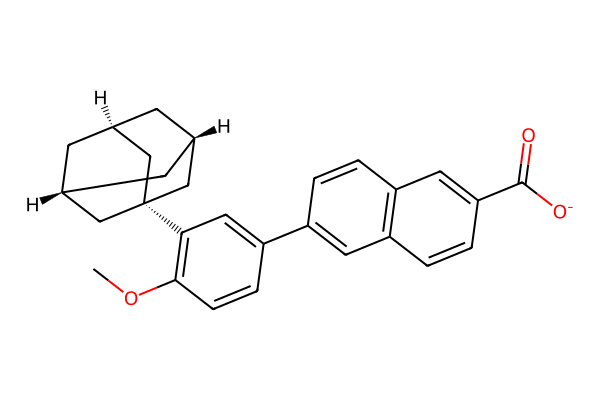
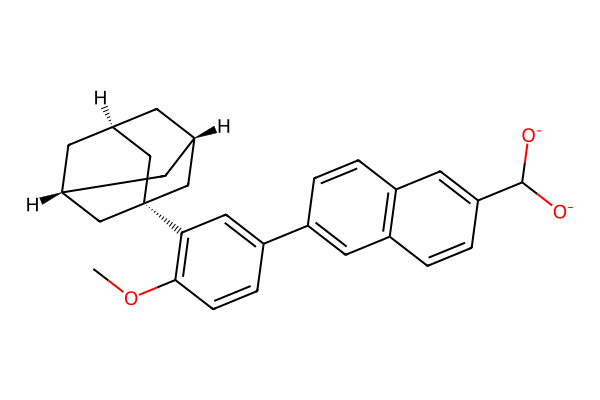
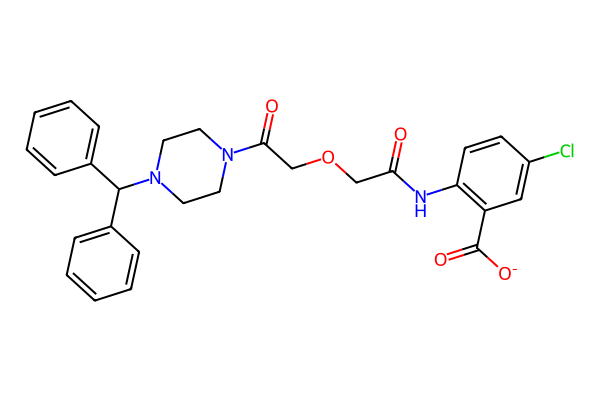
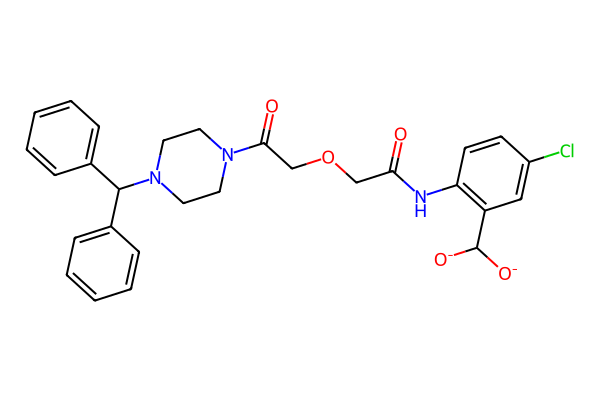
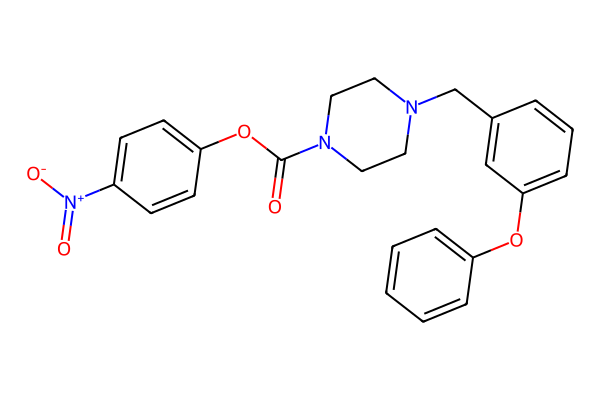
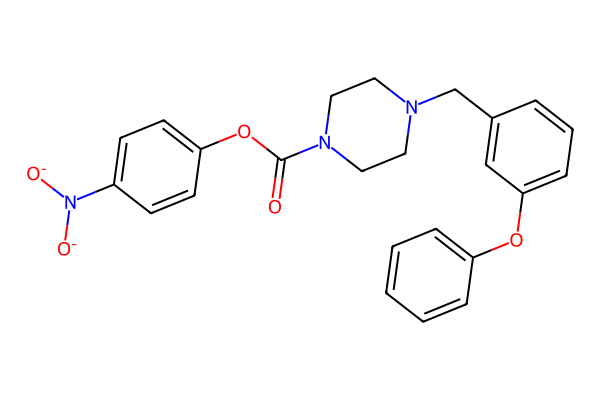
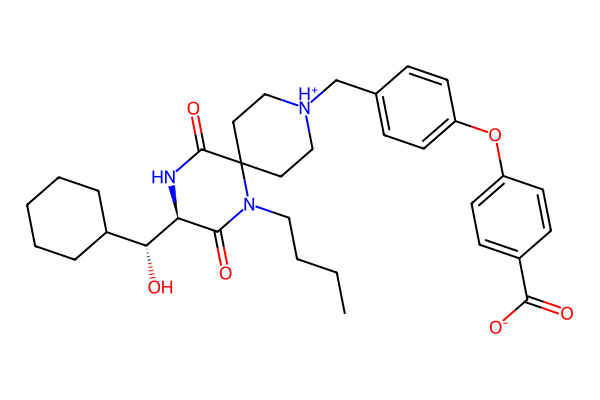
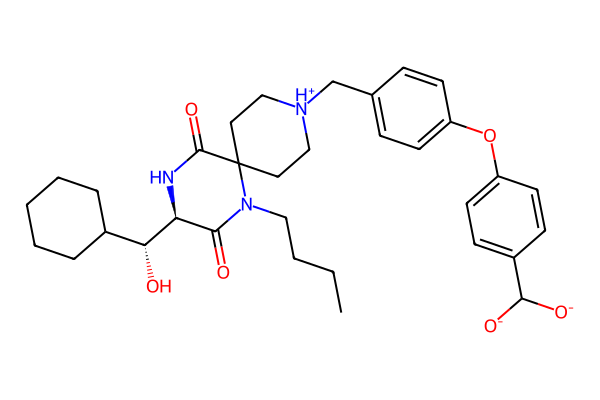
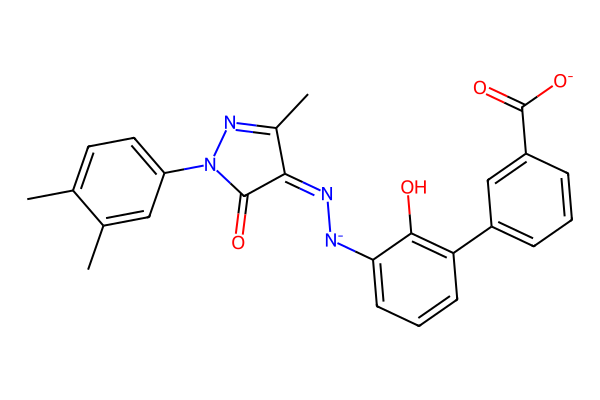
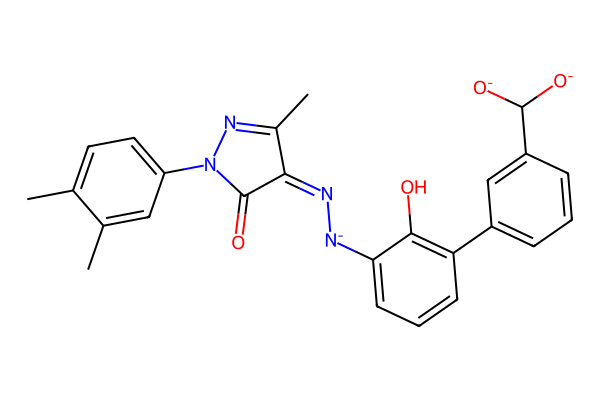

In [4]:
antechamber_ligs_directory = "test/ligs_anthechamber"
out_antechamber_ligs_sdf_path = "test/ligs_antechamber.sdf"

#####

pymol_helper.mol2_to_sdf(antechamber_ligs_directory, out_antechamber_ligs_sdf_path)

df_ligs = mol_df.df_from_sdf(out_md_ligs_sdf_path)
print(f"Number of source ligands: {df_ligs.shape[0]}")
df_ante = mol_df.df_from_sdf(out_antechamber_ligs_sdf_path).rename(columns={"Mol" : "Mol ante"})
print(f"Number of antechamber ligands: {df_ante.shape[0]}")

df_merged = df_ligs.merge(df_ante)
df_merged["SMILES"] = df_merged["Mol"].apply(lambda x: mdl.get_actual_smiles(x, kekuleSmiles=False))
df_merged["SMILES ante"] = df_merged["Mol ante"].apply(lambda x: mdl.get_actual_smiles(x, kekuleSmiles=False))
print(f"Number of merged ligands: {df_merged.shape[0]}")
df_merged[df_merged[["Mol", "Mol ante"]].apply(lambda x: mdl.get_actual_smiles(x[0], kekuleSmiles=False) != mdl.get_actual_smiles(x[1], kekuleSmiles=False), axis=1)]